这三个库（Seaborn, Plotly, Pandas plotting）是 Python 数据可视化生态系统的核心。掌握它们能极大地提升你的数据分析和展示能力。
我将为你提供一个全面的、分步的详细教程。

本教程结构如下：

Matplotlib：万物的基础
Seaborn 和 Plotly 对 Matplotlib 的主要改进

教程一：Seaborn 详细教程 (用于统计与美学)
教程二：Plotly 详细教程 (用于交互与网络)
教程三：Pandas 自带作图教程 (用于快速探索)


#### 总结：何时使用哪个库？


1. Matplotlib：万物的基础  
   
在学习其他库之前，必须了解 Matplotlib 是 Python 可视化的“祖父级”库。几乎所有其他库，包括 Seaborn 和 Pandas Plotting，底层都是构建在 Matplotlib 之上的。

* 优点：功能极其强大，控制力极强。你可以自定义图表的任何一个微小细节。
* 缺点：API 相对底层和繁琐，有时需要写很多代码才能实现一个简单的图表，且默认样式不够美观。


2. Seaborn 和 Plotly 对 Matplotlib 的主要改进  
   
这两个库的出现，就是为了解决 Matplotlib 的缺点。


Seaborn 的改进：  

1.1. 更简洁的 API：用更少的代码创建更复杂的统计图表。例如，在 Matplotlib 中画一个带回归线的散点图可能需要多行代码，而在 Seaborn 中通常只需一行。  

1.2. 更美观的默认样式：Seaborn 的默认主题、调色板和样式远比 Matplotlib 的现代和美观，几乎无需调整即可生成“出版级”的图表。 

1.3. 专注于统计可视化：Seaborn 内置了许多专门用于展示统计关系的功能，如分布图、分类数据图、线性模型可视化等，这是 Matplotlib 所不具备的。  

1.4. 与 Pandas 的深度集成：Seaborn 的函数设计能够非常自然地接受 Pandas DataFrame 作为输入，并能轻松地使用列名来分配颜色、大小、样式等。 

一句话总结 Seaborn：让 Matplotlib 变得更简单、更美观，并专注于统计分析。  


Plotly 的改进：  

2.1. 原生交互性 (Interactive)：这是 Plotly 最大的优势。用 Plotly 生成的图表是交互式的。你可以用鼠标悬停查看数据、缩放、平移、点击图例来隐藏/显示数据，而这一切都无需额外代码。Matplotlib 和 Seaborn 生成的默认是静态图片。

2.2. Web 原生：Plotly 的图表是基于 JSON 和 JavaScript (Plotly.js) 构建的。这意味着你可以轻松地将图表嵌入到网页、在线报告和 Dash 应用中，它们看起来和行为都像现代的网络应用元素。

2.3. 更现代的图表类型：Plotly 提供了许多 Matplotlib/Seaborn 不容易实现的现代图表，如旭日图 (Sunburst)、平行坐标图、三维网络图、地理地图（Choropleth maps）等。

2.4. 声明式 API (Plotly Express)：Plotly Express 提供了一个极其简洁的声明式 API，你只需“声明”你想要的数据和映射方式，它就会为你生成一个完整的、交互式的图表。

一句话总结 Plotly：它不是对 Matplotlib 的“改进”，而是一个全新的、为交互式和网络时代打造的可视化引擎。



#### 教程一：Seaborn 详细教程
目标：用最少的代码创建美观的统计图表。

第一步：安装和导入


!pip install seaborn matplotlib pandas

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 

第二步：核心概念 - Figure-level vs. Axes-level
* Axes-level 函数：在一个已经存在的 matplotlib.pyplot.Axes 对象上绘图（例如 scatterplot, histplot, boxplot）。你可以精确控制每个子图画什么。
* Figure-level 函数：会自己创建一个 Matplotlib Figure 和 Axes，并能轻松创建分面网格（多个子图）。例如 relplot, displot, catplot。

第三步：加载数据

Seaborn 自带一些示例数据集，非常适合学习。

In [2]:
# 加载 "tips" (小费) 数据集
tips = sns.load_dataset("tips")
print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [3]:
tips.shape

(244, 7)

第四步：常用图表实战
1. 分布图 (Distribution Plots) - 查看单个变量的分布
直方图 (histplot)

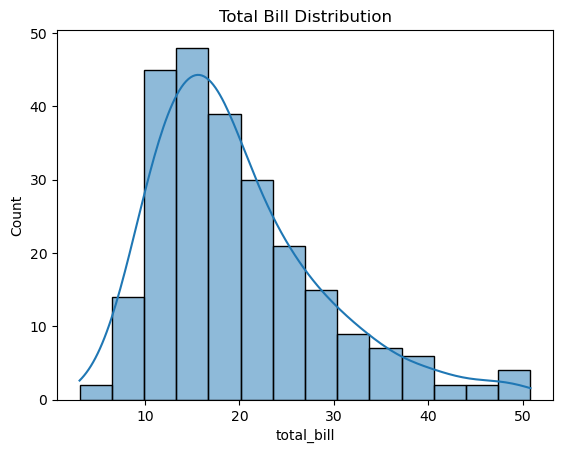

In [4]:
sns.histplot(data=tips, x="total_bill", kde=True) # kde=True 会加上KDE曲线
plt.title("Total Bill Distribution")
plt.show()

核密度估计图 (kdeplot) - 平滑版的直方图

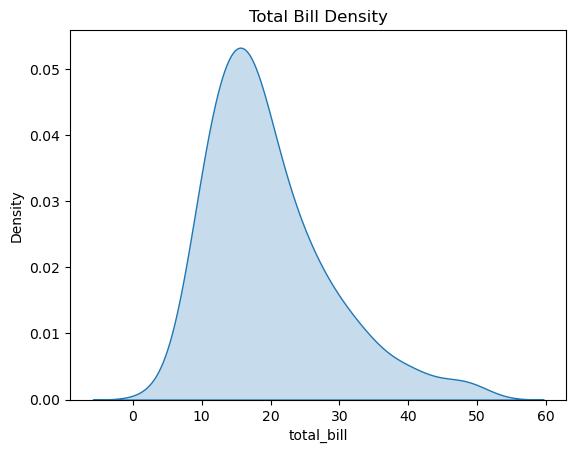

In [5]:
sns.kdeplot(data=tips, x="total_bill", fill=True) # fill=True 填充曲线下方
plt.title("Total Bill Density")
plt.show()

2. 关系图 (Relational Plots) - 查看两个变量间的关系
散点图 (scatterplot)
使用 hue 参数引入第三个分类变量，用颜色区分。

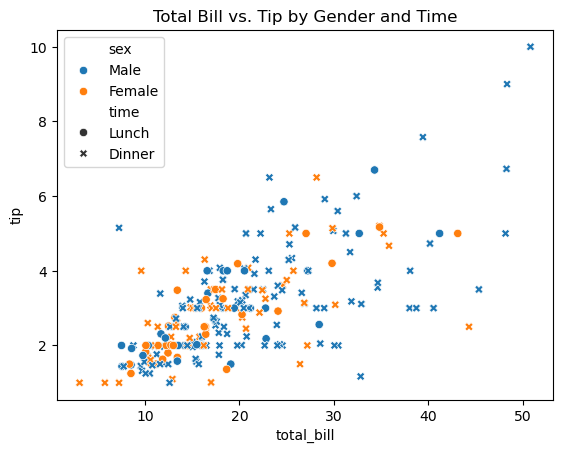

In [6]:
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="sex", style="time")
plt.title("Total Bill vs. Tip by Gender and Time")
plt.show()

3. 分类图 (Categorical Plots) - 查看数值变量在不同类别下的分布

箱形图 (boxplot) - 查看中位数、四分位数和异常值

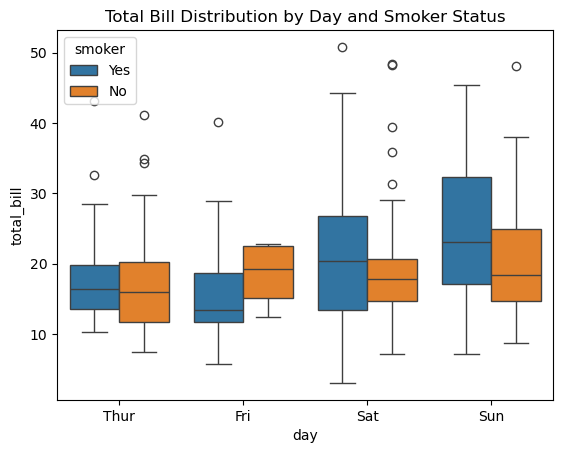

In [7]:
sns.boxplot(data=tips, x="day", y="total_bill", hue="smoker")
plt.title("Total Bill Distribution by Day and Smoker Status")
plt.show()

小提琴图 (violinplot) - 箱形图和核密度估计的结合

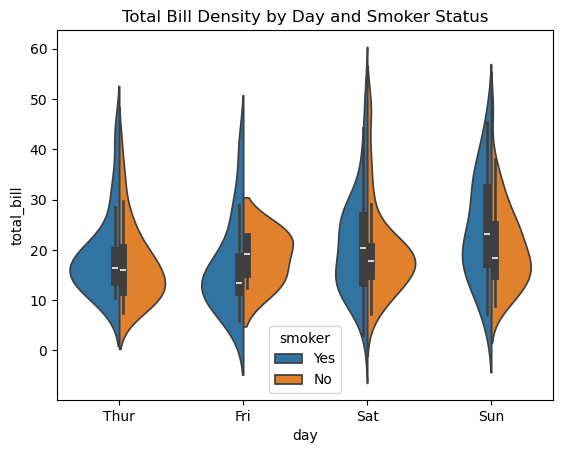

In [8]:
sns.violinplot(data=tips, x="day", y="total_bill", hue="smoker", split=True) # split=True 将hue的两个类别画在同一个小提琴的两侧
plt.title("Total Bill Density by Day and Smoker Status")
plt.show()

4. 矩阵图 (Matrix Plots) - 查看多个变量间的关系


热力图 (heatmap) - 展示矩阵数据的相关性

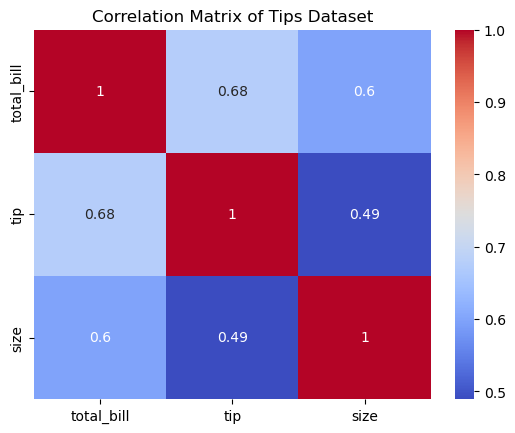

In [9]:
# 首先计算数值列的相关性矩阵
numeric_cols = tips.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm") # annot=True 在格子上显示数值
plt.title("Correlation Matrix of Tips Dataset")
plt.show()

4. 教程二：Plotly 详细教程
目标：创建交互式的、适合网页展示的图表。
第一步：安装和导入

我们主要使用 plotly.express，它是 Plotly 的高级封装，非常易用。

In [2]:
import plotly.express as px
import pandas as pd

第二步：加载数据
Plotly 也自带一些非常好的示例数据集。

In [3]:
# 加载 Gapminder 数据集，包含各国多年的经济指标
gapminder = px.data.gapminder()
print(gapminder.head())

       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


第三步：常用图表实战 (体验交互性)
1. 散点图 (px.scatter)
交互性：将鼠标悬停在点上可以看到详细数据。
参数：size 和 color 可以轻松映射到数据列。
动画：animation_frame 参数可以创建动画！

In [4]:
# 2007年的数据
gapminder_2007 = gapminder.query("year==2007")

fig = px.scatter(
    gapminder_2007,
    x="gdpPercap",
    y="lifeExp",
    color="continent",          # 按大洲着色
    size="pop",                 # 按人口大小调整点的大小
    hover_name="country",       # 鼠标悬停时显示国家名称
    log_x=True,                 # X轴使用对数刻度
    size_max=60,                # 最大点的大小
    title="Life Expectancy vs. GDP per Capita (2007)"
)
fig.show() # 在Jupyter Notebook或浏览器中显示交互式图表

2. 条形图 (px.bar)

In [5]:
# 计算每个大洲的平均GDP
continent_gdp = gapminder.groupby('continent')['gdpPercap'].mean().reset_index()

fig = px.bar(
    continent_gdp,
    x='continent',
    y='gdpPercap',
    color='continent',
    title="Average GDP per Capita by Continent"
)
fig.show()

3. 动画散点图 (Plotly 的“杀手级”功能)

In [6]:
fig = px.scatter(
    gapminder,
    x="gdpPercap",
    y="lifeExp",
    color="continent",
    size="pop",
    hover_name="country",
    log_x=True,
    size_max=60,
    animation_frame="year", # 按年份创建动画帧
    animation_group="country", # 确保每个国家在动画中是连续的
    range_y=[20, 90], # 锁定Y轴范围
    title="The Evolution of Health and Wealth of Nations"
)
fig.show()

4. 地理地图 (px.choropleth)

In [7]:
fig = px.choropleth(
    gapminder,
    locations="iso_alpha", # 国家三字母代码
    color="lifeExp",       # 按人均寿命着色
    hover_name="country",
    animation_frame="year",
    color_continuous_scale=px.colors.sequential.Plasma,
    title="Global Life Expectancy Over Time"
)
fig.show()

5. 教程三：Pandas 自带作图教程
目标：直接在 DataFrame 上进行快速、便捷的可视化探索。
见 4_pandas 文件夹